In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
import matplotlib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


from sklearn.ensemble import RandomForestRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

import joblib

import warnings
%matplotlib inline
warnings.filterwarnings("ignore")

# Service functions

In [2]:
def get_cols(df) -> list:
    '''
    function return list of name numbers and categorials columns
    '''
    categorical_feature_mask = df.dtypes == object
    number_feature_mask = df.dtypes != object
    numbers_cols = df.columns[number_feature_mask].tolist()
    categorical_cols = df.columns[categorical_feature_mask].tolist()
    return [numbers_cols, categorical_cols]

In [3]:
scalers_categorial = {'LabelEncoder': LabelEncoder(), 
                     'TargetEncoder': TargetEncoder()}

mls = {
        'GradientBoostingRegressor': GradientBoostingRegressor(random_state=0), 
        'linear': LinearRegression(), 'RandomForestRegressor':RandomForestRegressor(max_depth=2, random_state=0),
        'LassoCV': LassoCV(), 'Ridge': RidgeCV(), 'ElasticNetCV': ElasticNetCV(),
       'ExtraTreesRegressor': ExtraTreesRegressor(n_estimators=100, random_state=0)
        }

scalers = {'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler(),
           'RobustScaler': RobustScaler(), 'Normalizer': Normalizer(), 'Not scaled': 0}

In [4]:
def encode_categorial(name_scaler, scaler, data, y = None, return_scaler = False):
    if name_scaler != 'TargetEncoder':
        if not return_scaler:
            return data[categorical_cols].apply(lambda x: scaler.fit_transform(x.astype(str)))
        else:
            return data[categorical_cols].apply(lambda x: scaler.fit_transform(x.astype(str))), scaler
    else:
        if not return_scaler:
            return scaler.fit_transform(data[categorical_cols], y)
        else:
            return scaler.fit_transform(data[categorical_cols], y), scaler
    
def encode_number(name_scaler, scaler, data, return_scaler = False):
    if name_scaler == 'Not scaled':
        if not return_scaler:
            return data
        else:
            return data, scaler
    else:
        if not return_scaler:
            return scaler.fit_transform(data)
        else:
            return scaler.fit_transform(data), scaler

# Exploratory data analysis

In [5]:
file_name = '/kaggle/input/car-price-prediction-challenge/car_price_prediction.csv'
df = pd.read_csv(file_name)
df.head(2)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8


In [6]:
df.drop(columns=['ID'], inplace=True)

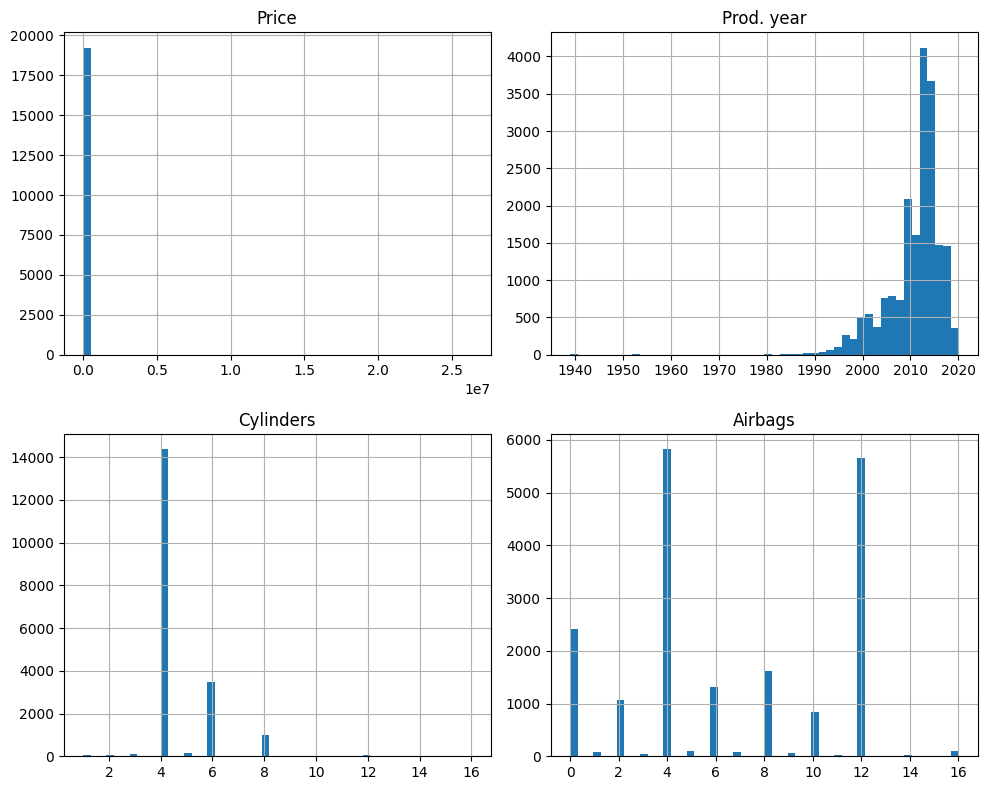

In [7]:
df.hist(bins=50, figsize=(10,8))
plt.rcParams['figure.figsize'] = [20, 10]
plt.tight_layout() 
plt.show()

# Empty data

In [8]:
# empty data of even columns
cols = df.apply(lambda x: f'{(x.isna().sum()/df.shape[0]).round(3)} %').sort_values(ascending = False)
print(cols)

Price               0.0 %
Mileage             0.0 %
Color               0.0 %
Wheel               0.0 %
Doors               0.0 %
Drive wheels        0.0 %
Gear box type       0.0 %
Cylinders           0.0 %
Engine volume       0.0 %
Levy                0.0 %
Fuel type           0.0 %
Leather interior    0.0 %
Category            0.0 %
Prod. year          0.0 %
Model               0.0 %
Manufacturer        0.0 %
Airbags             0.0 %
dtype: object


## Categorials columns

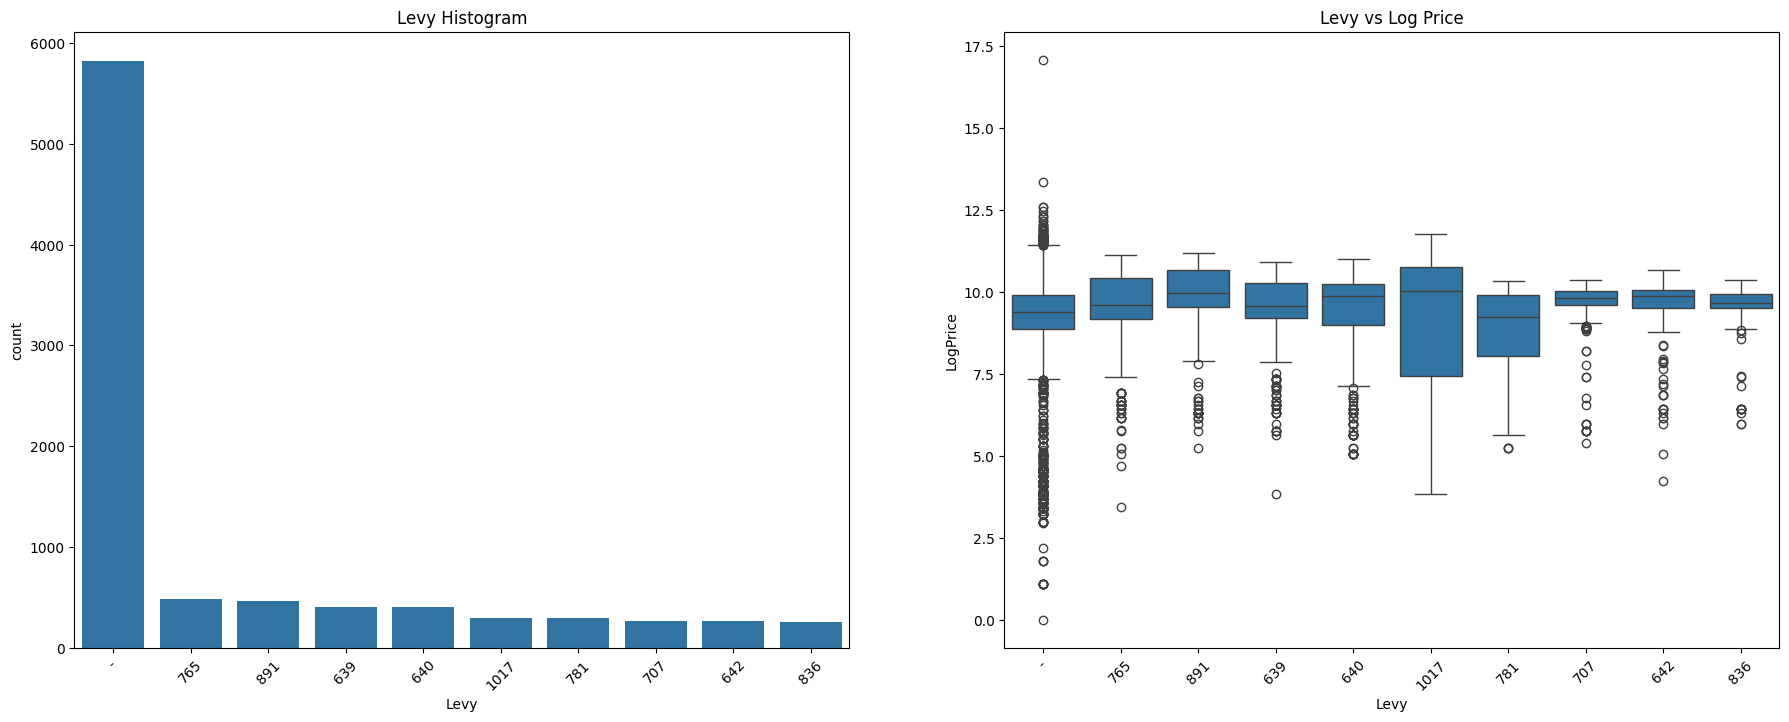

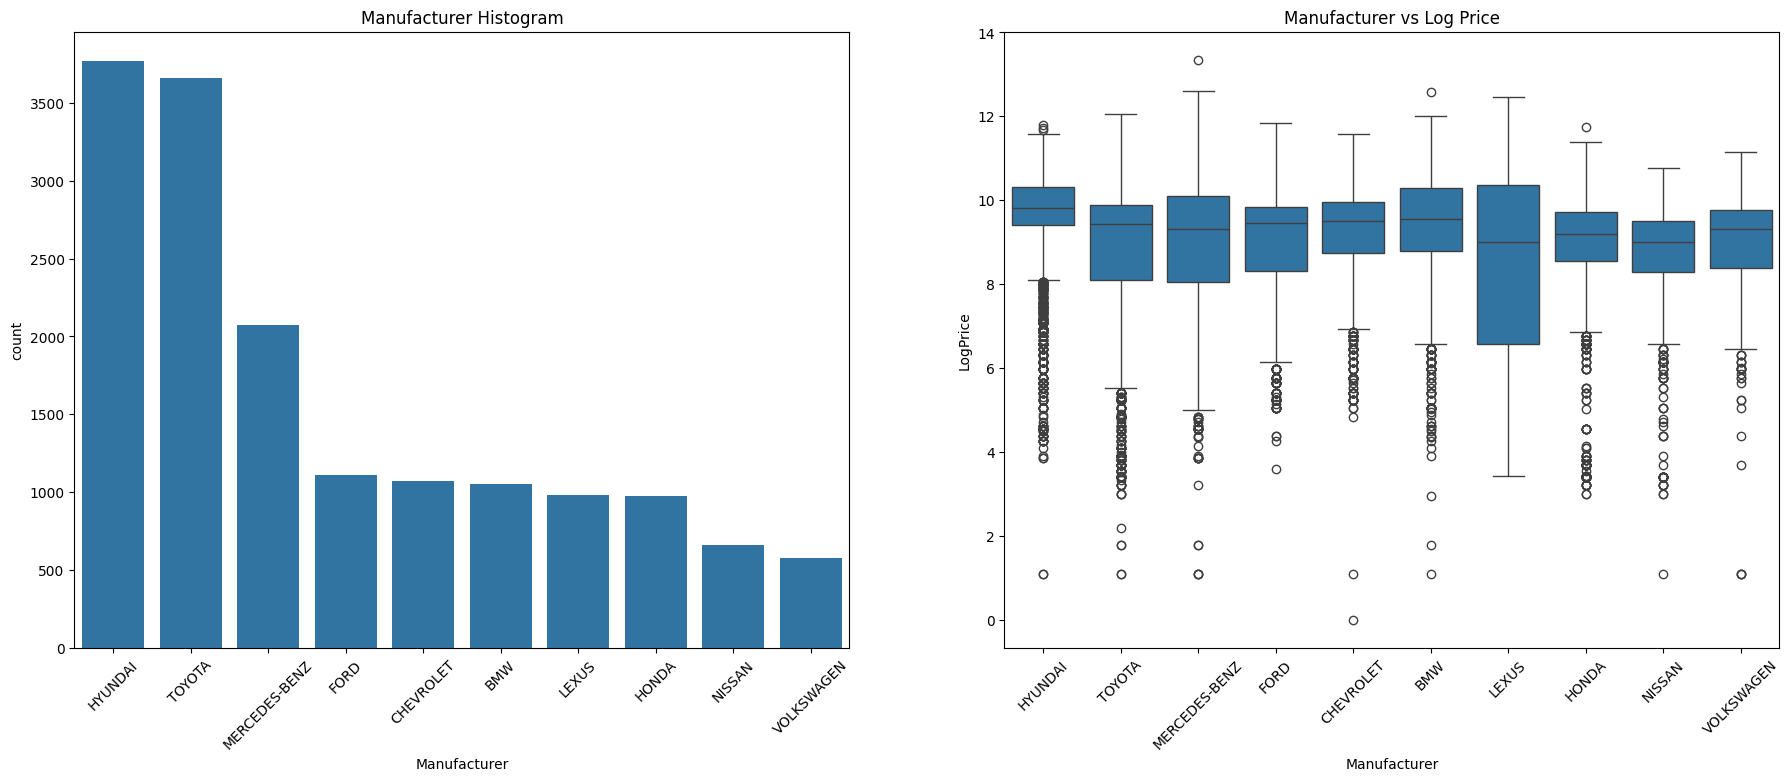

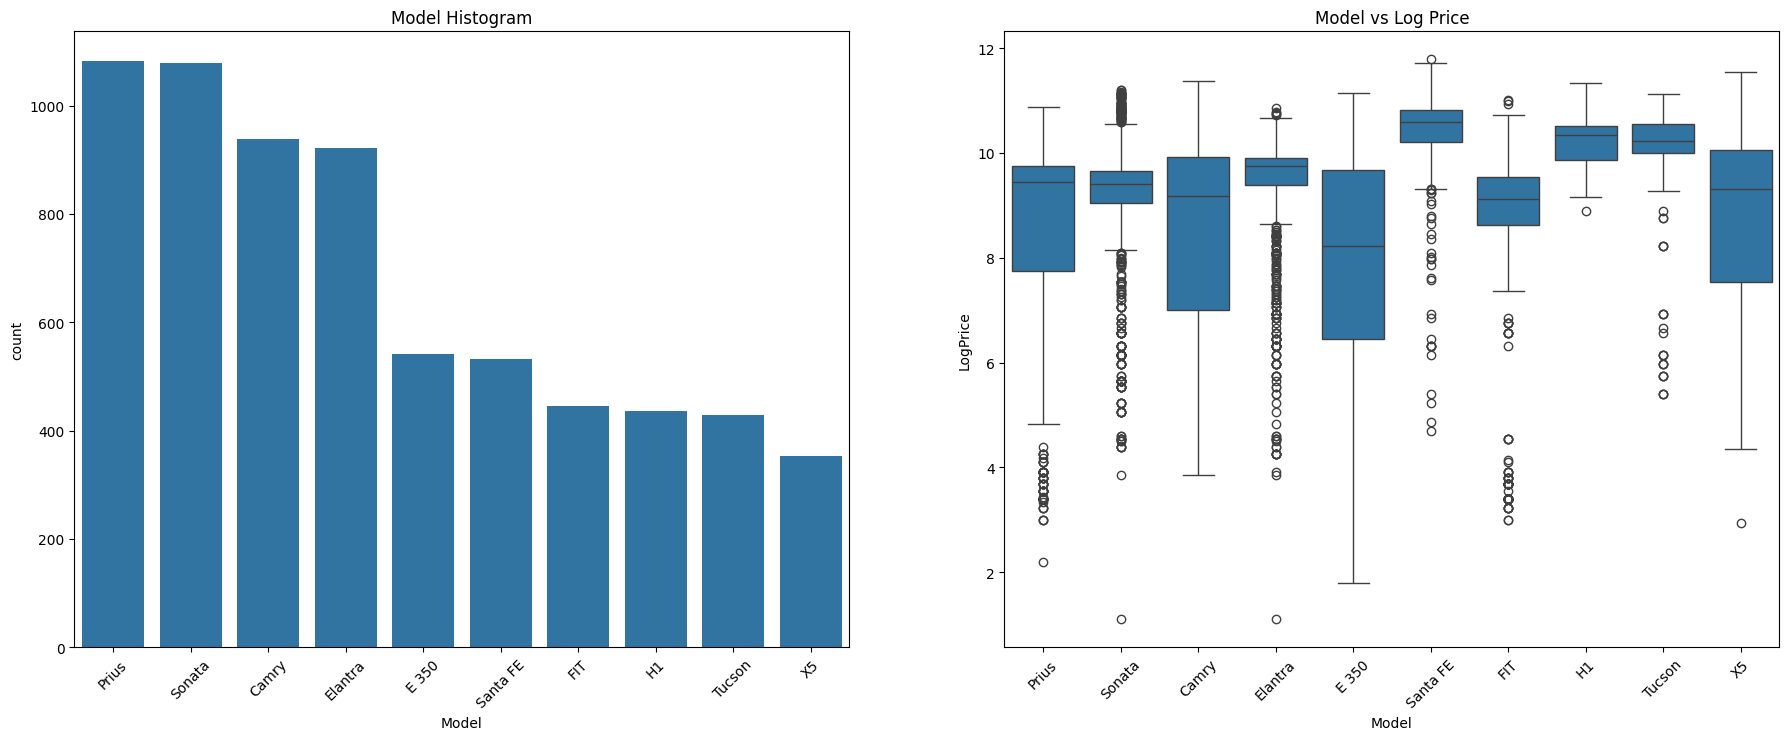

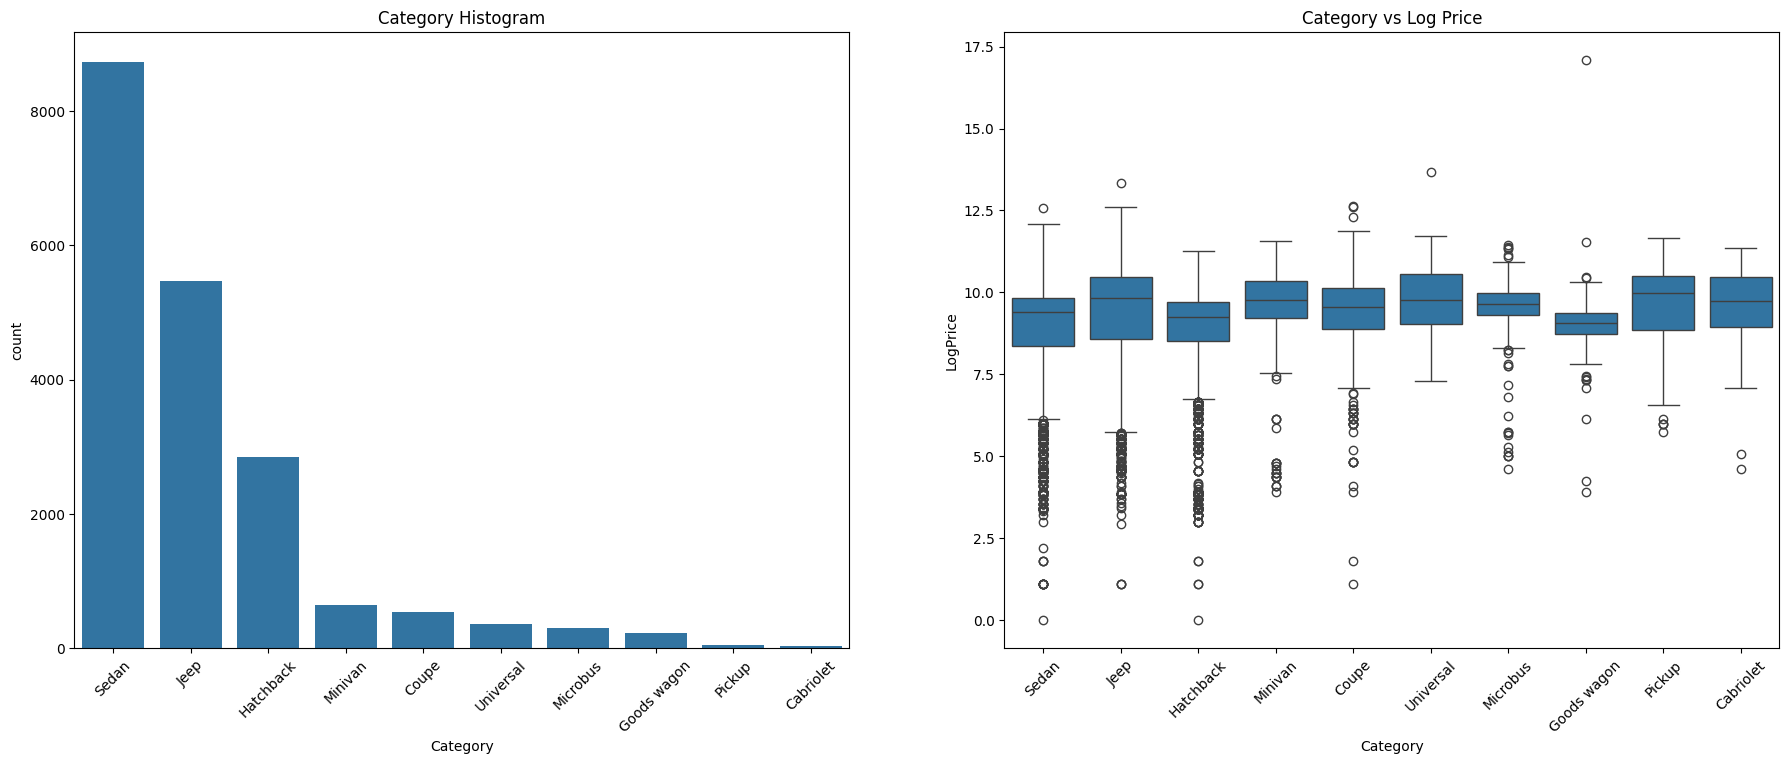

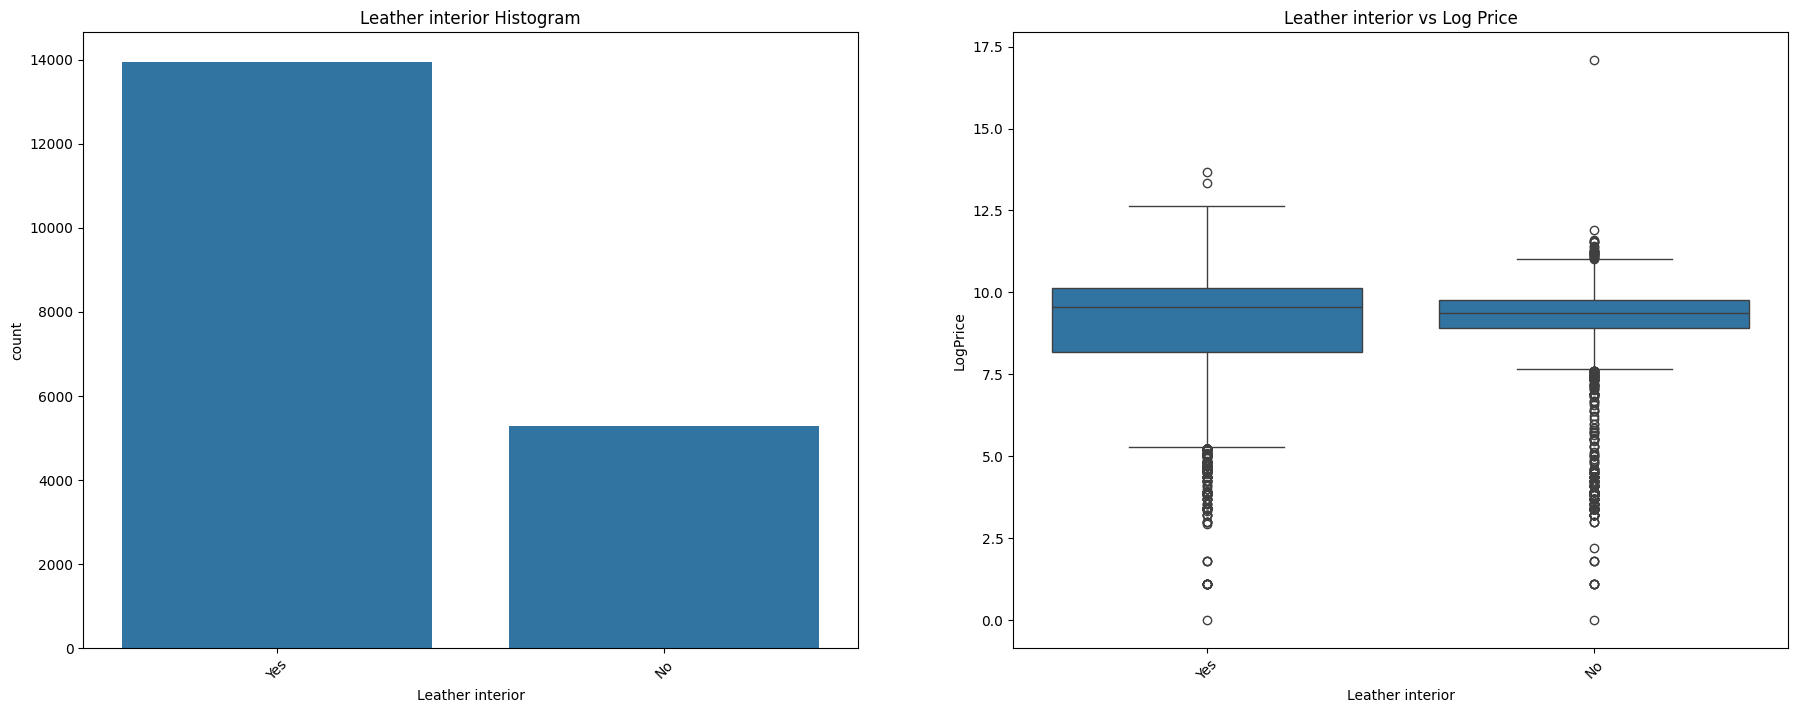

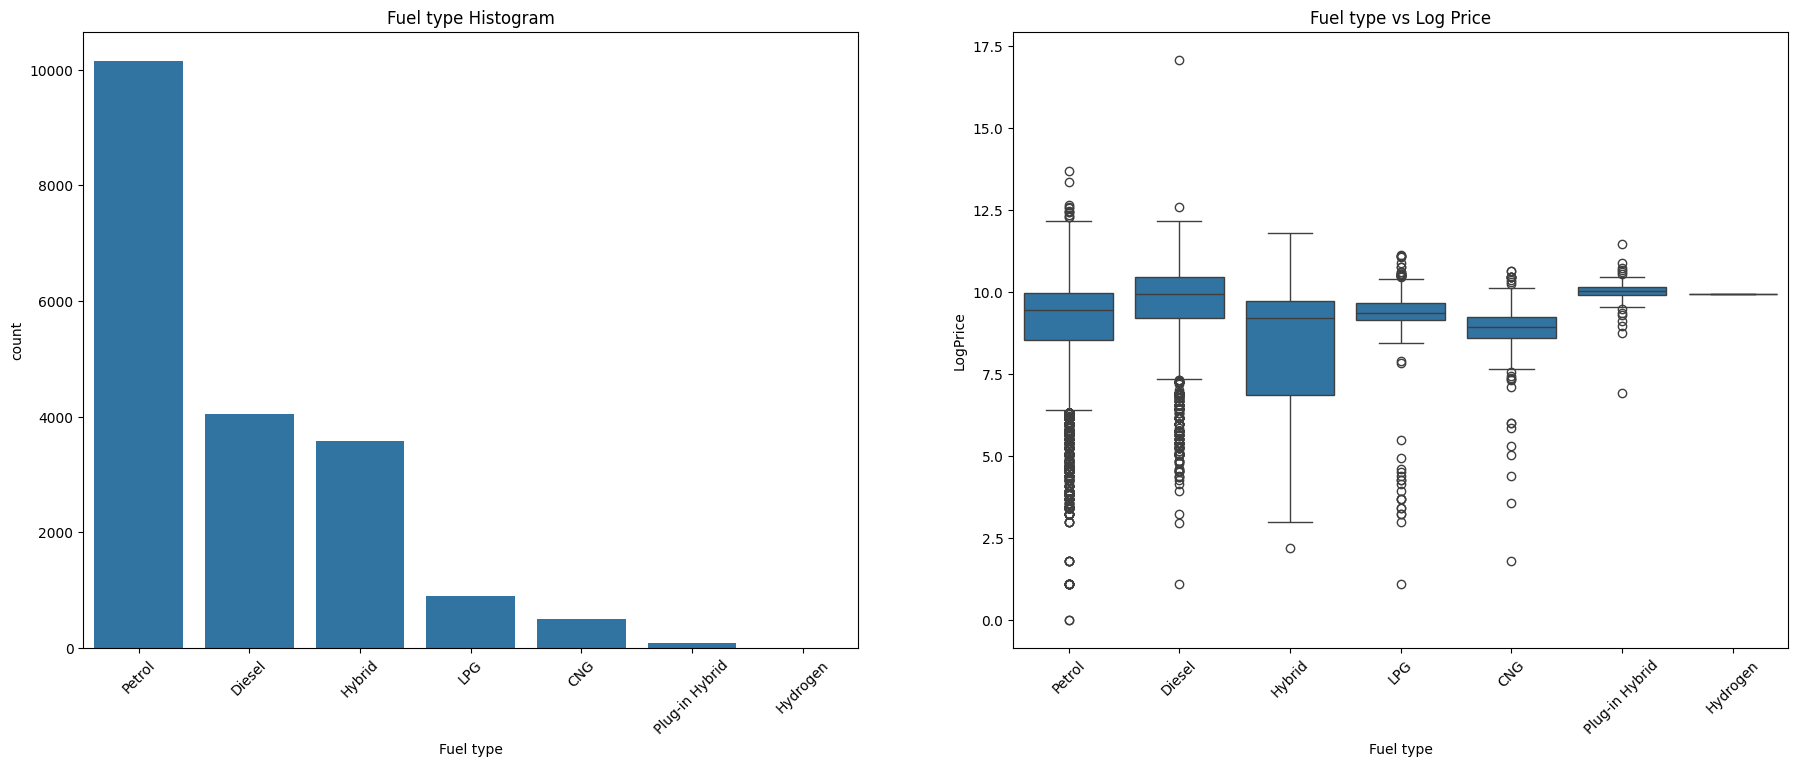

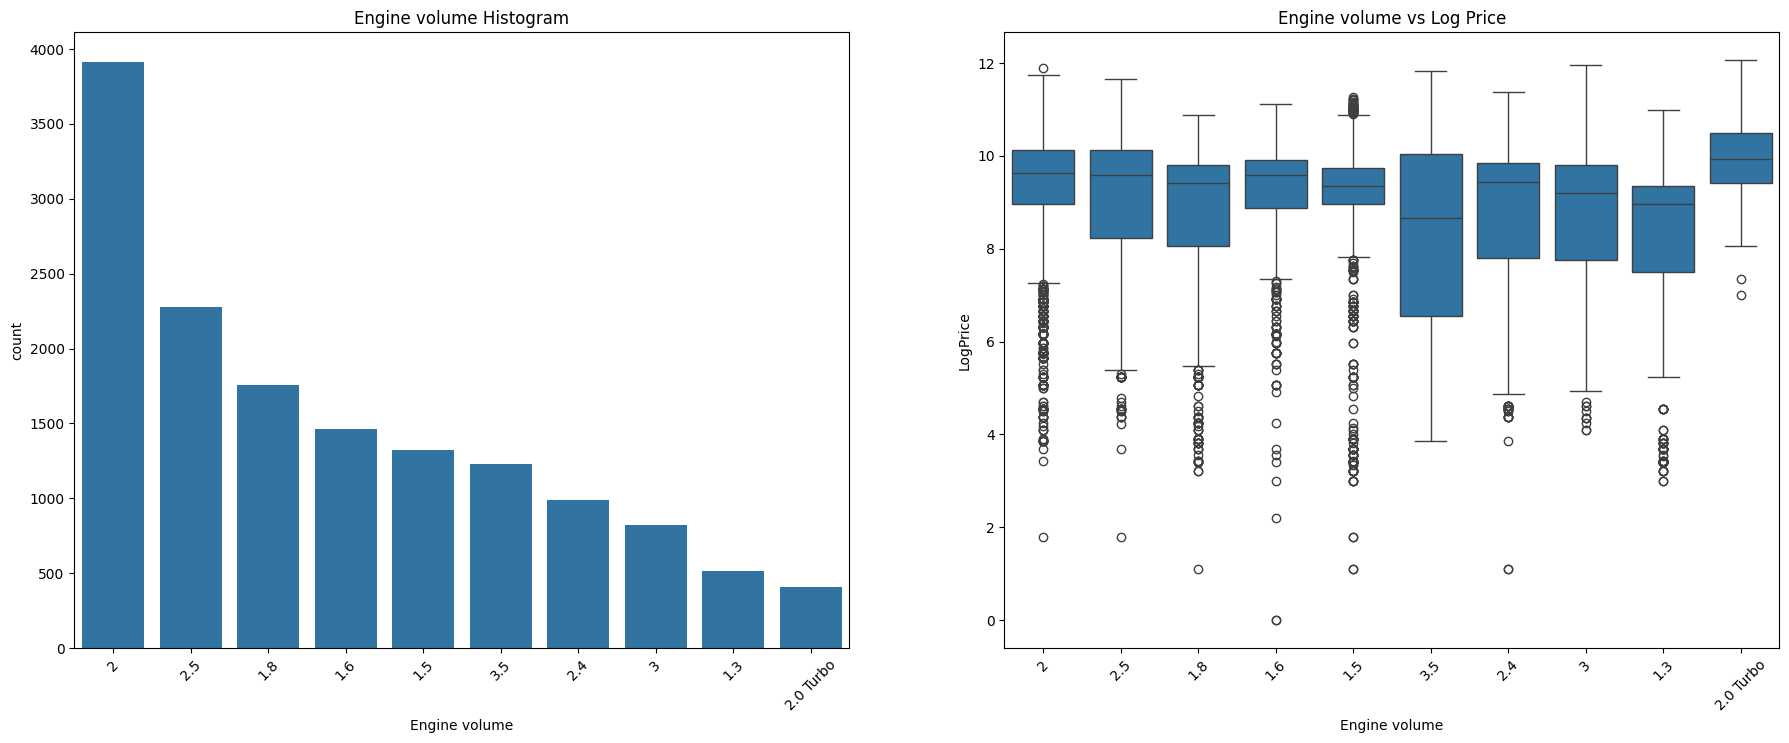

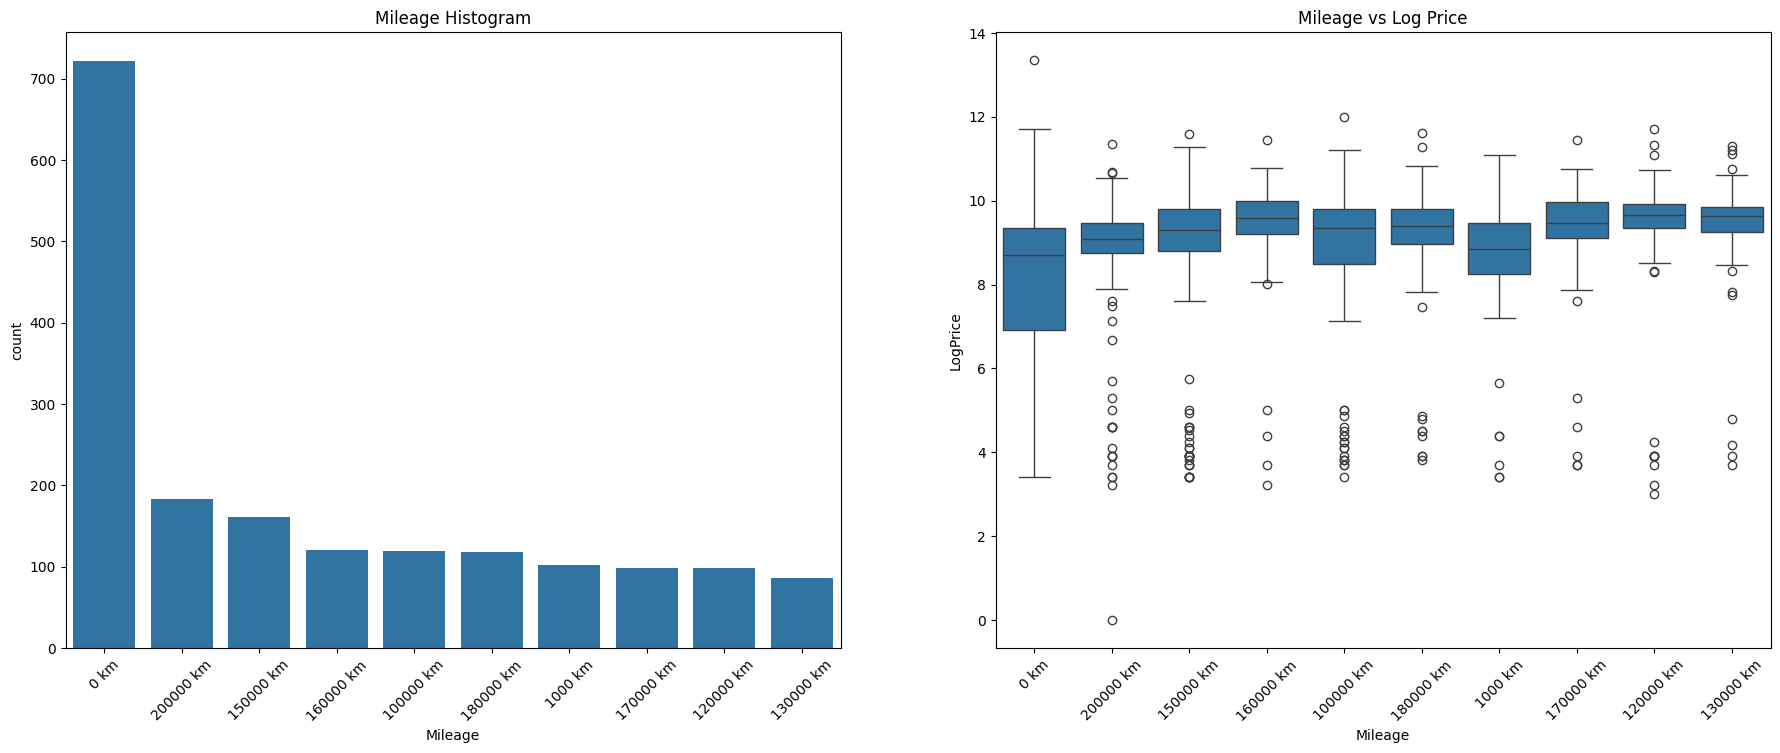

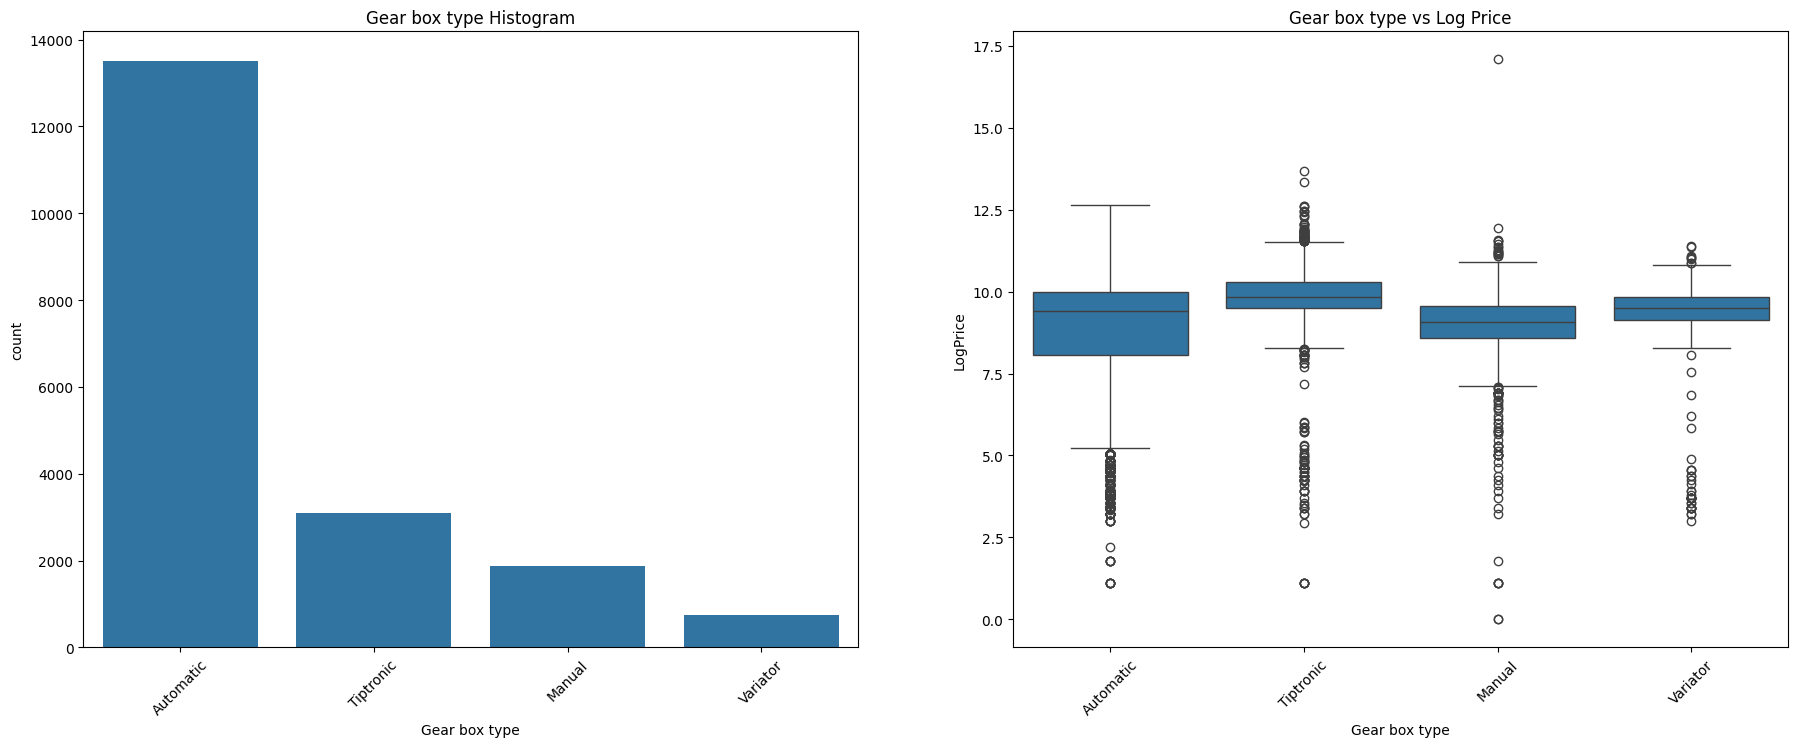

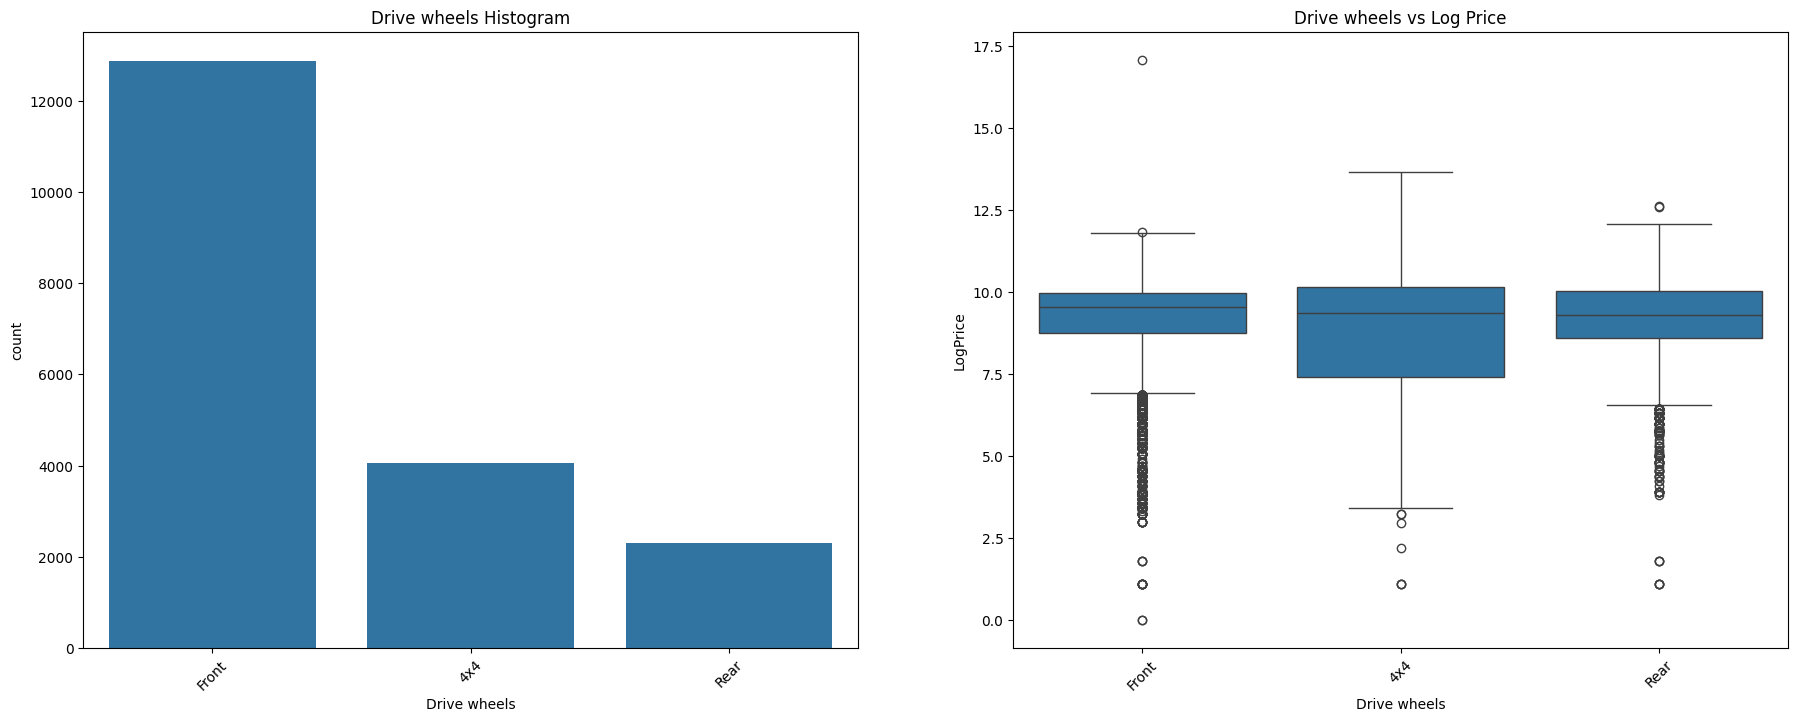

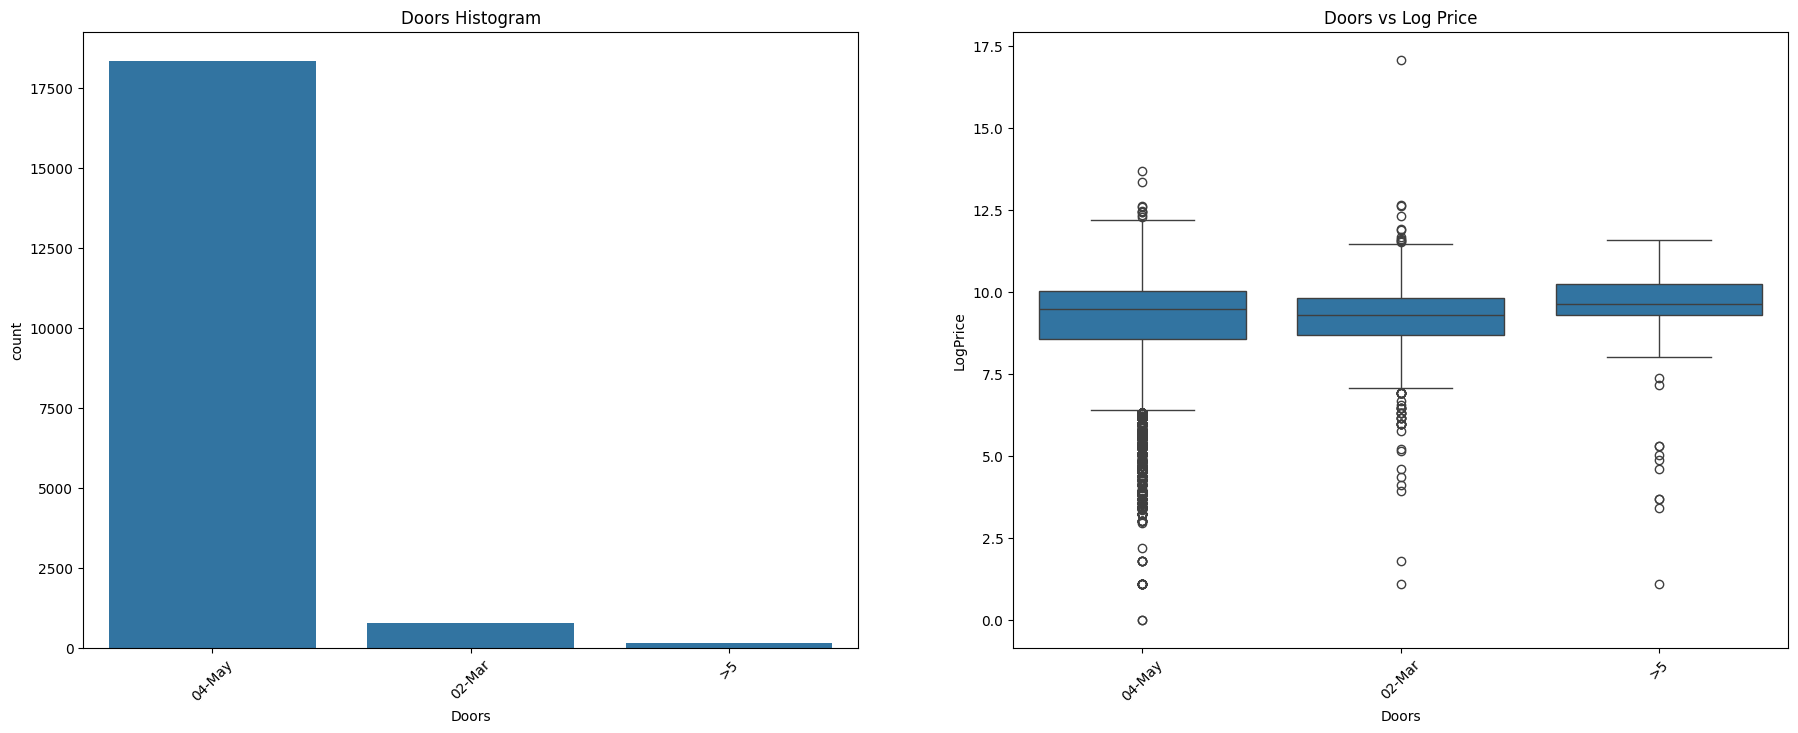

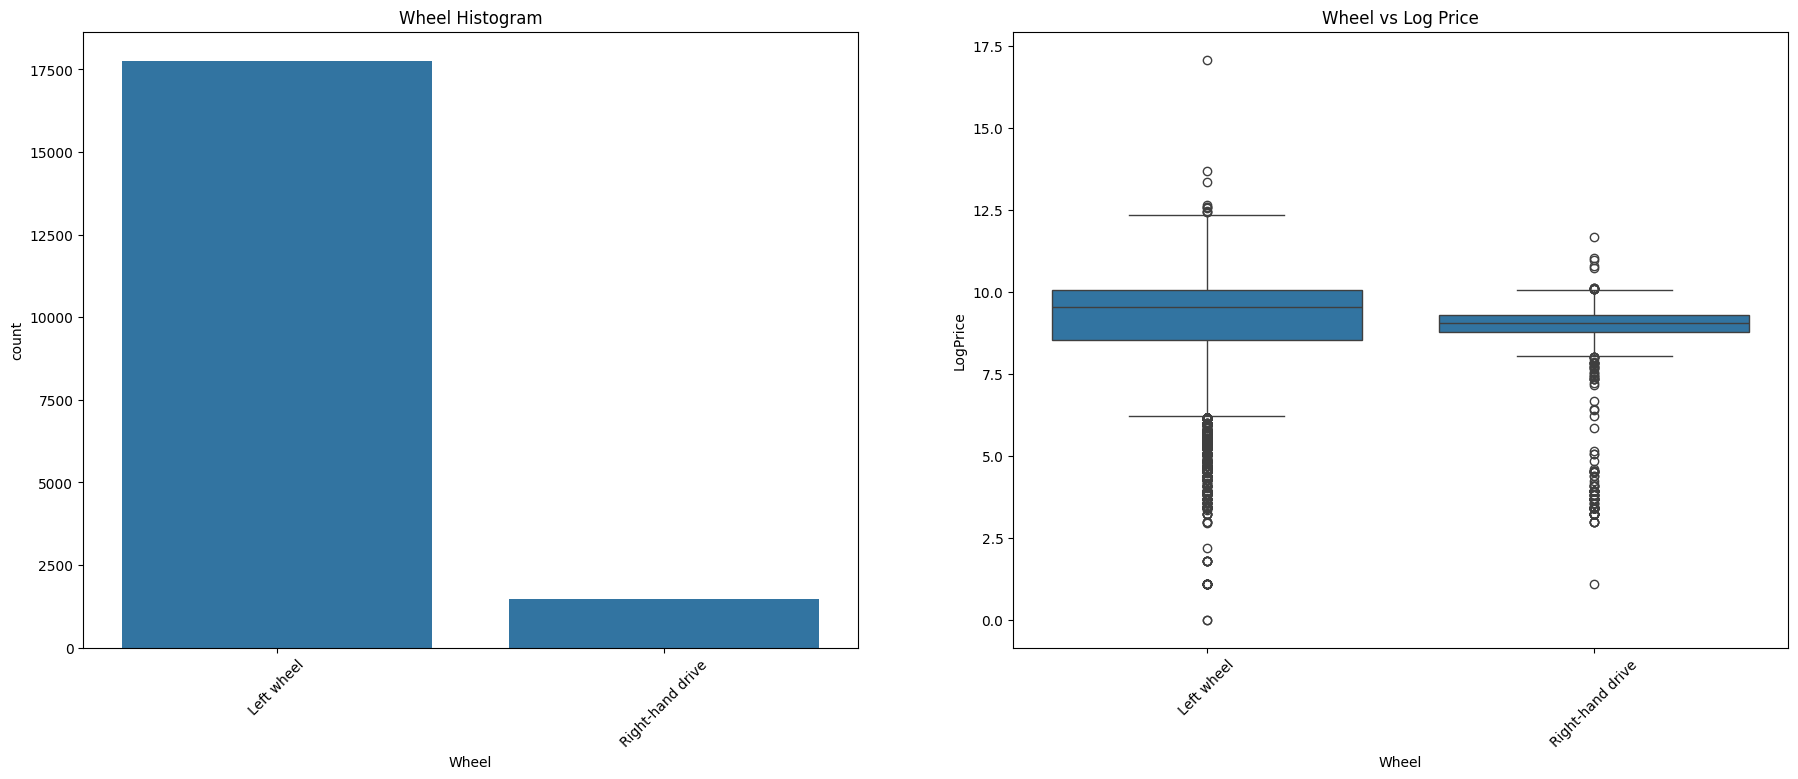

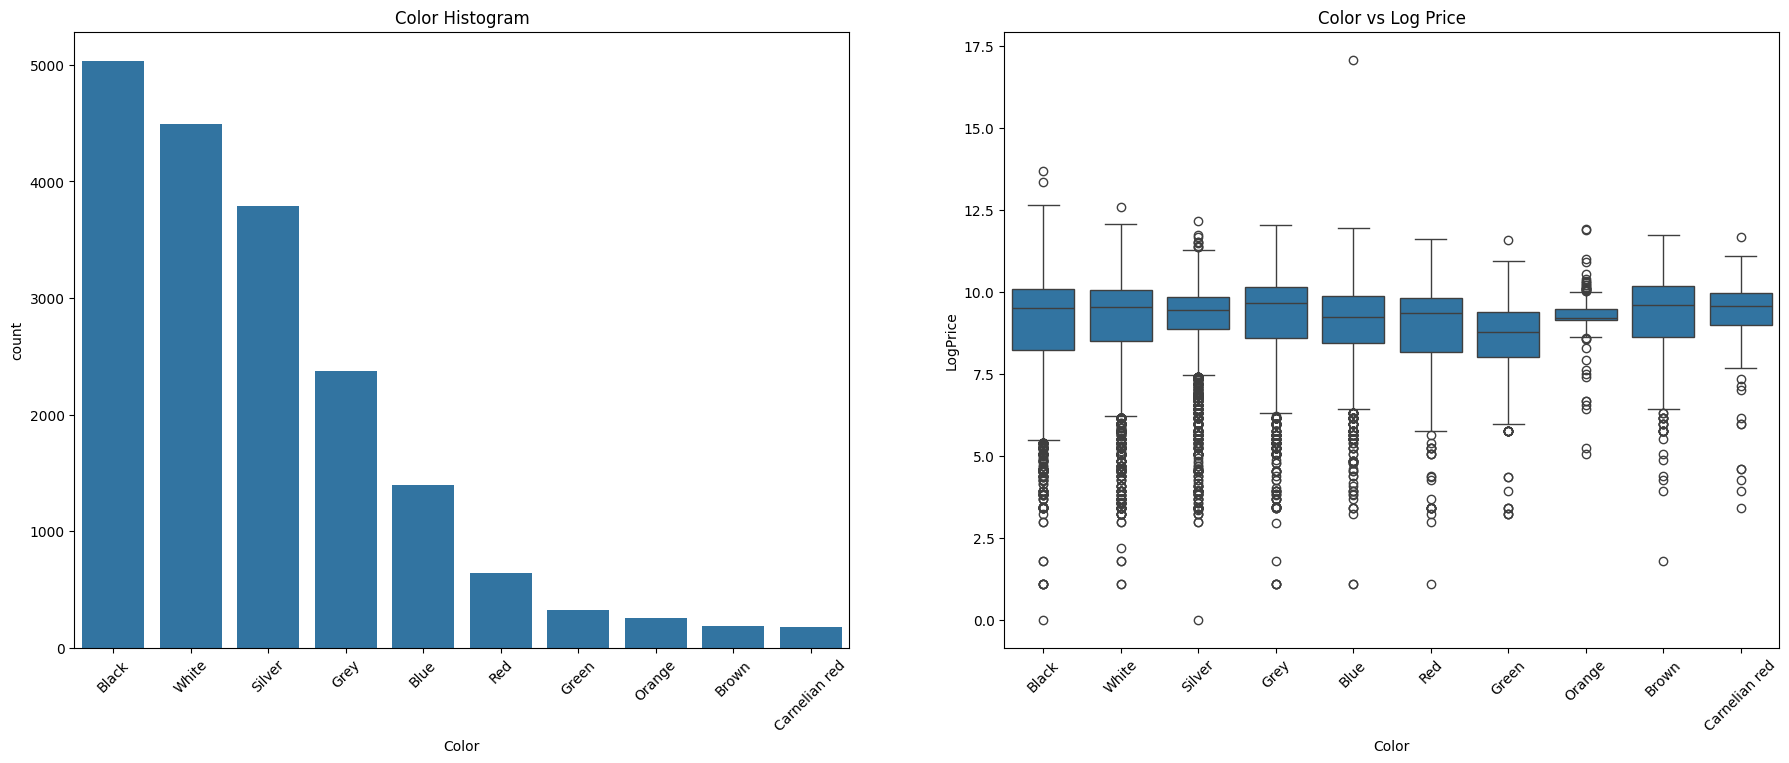

In [9]:
numbers_cols, categorical_cols = get_cols(df)
for column in categorical_cols:
    # Recovery of the 10 most frequent values (excluding empty strings)
    counts = df[column].value_counts()
    if '' in counts.index:
        counts = counts.drop('')
    columne_most_freq = counts.head(10).index
    
    # Filtrage 
    df_filtered = df[df[column].isin(columne_most_freq)]
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))    
    
    #  Histogramme
    plt.subplot(1, 2, 1)
    plt.title(f'{column} Histogram')
    sns.countplot(data=df_filtered, x=column, order=columne_most_freq)
    plt.xticks(rotation=45)

    #  Boxplot vs Log Price
    plt.subplot(1, 2, 2)
    plt.title(f'{column} vs Log Price')
    # Ajout d'une colonne temporaire pour le Log Price pour éviter les erreurs de dimension
    df_filtered = df_filtered.assign(LogPrice=np.log(df_filtered['Price']))
    sns.boxplot(data=df_filtered, x=column, y='LogPrice', order=columne_most_freq)
    plt.xticks(rotation=45)

    plt.show()

## Quantitative columns

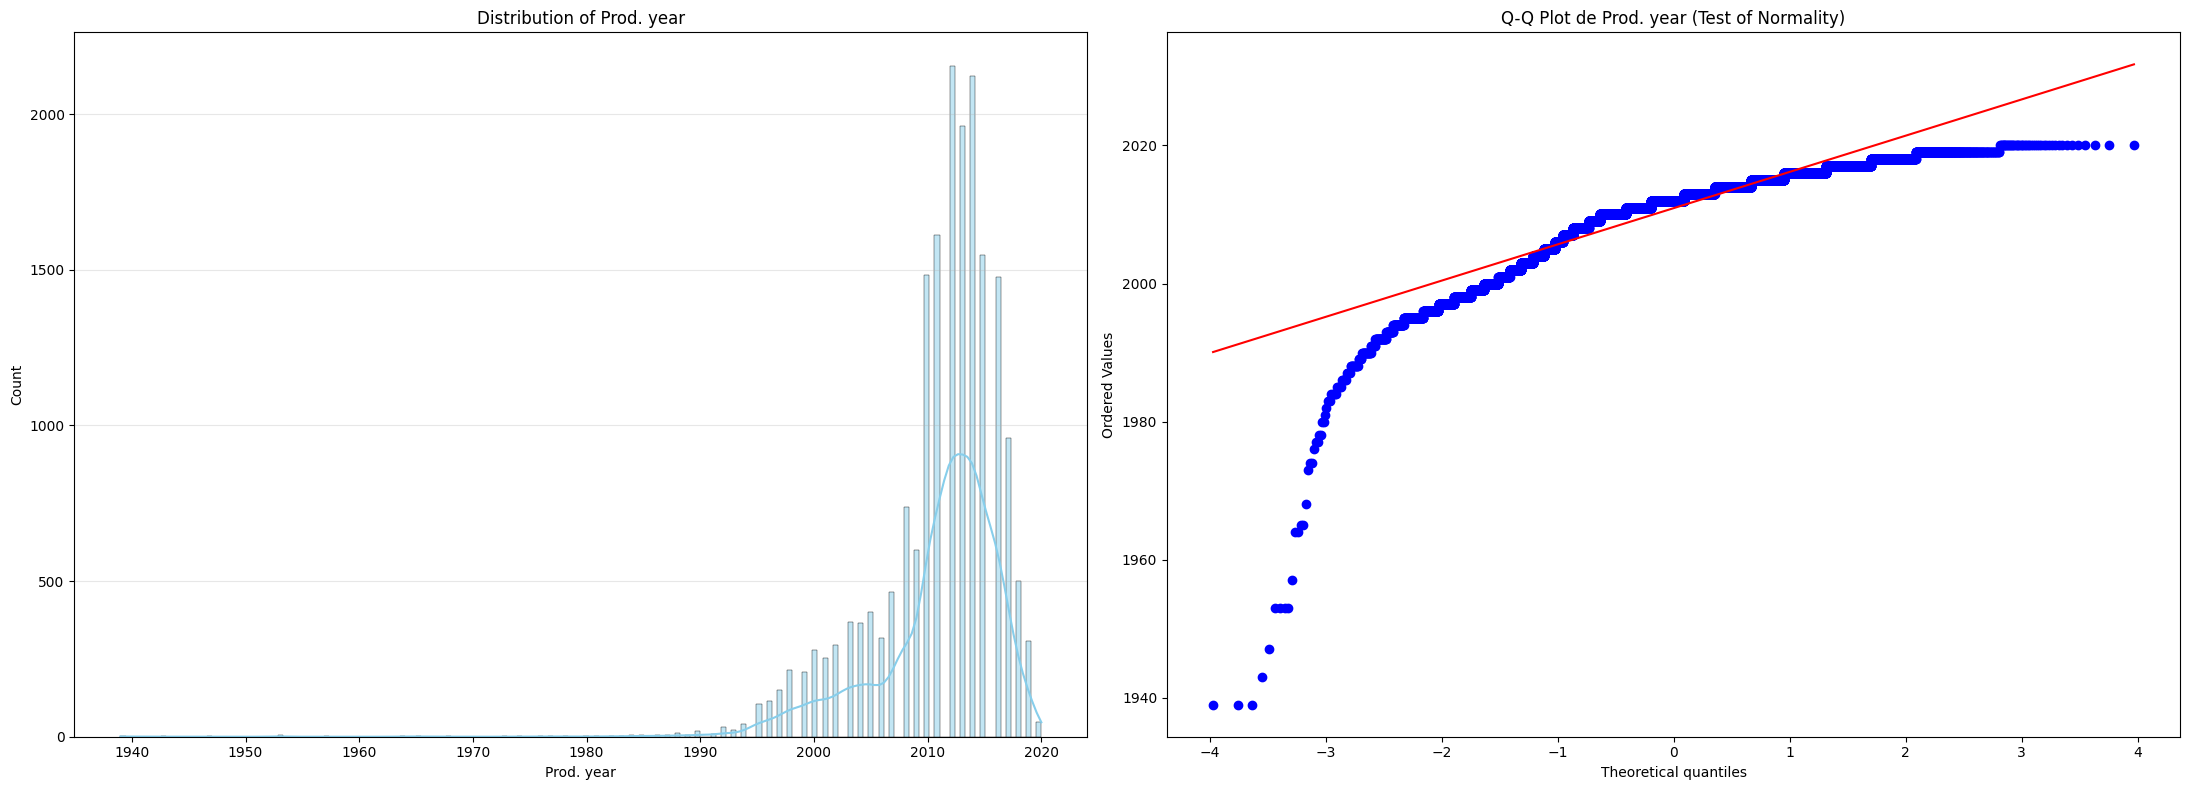

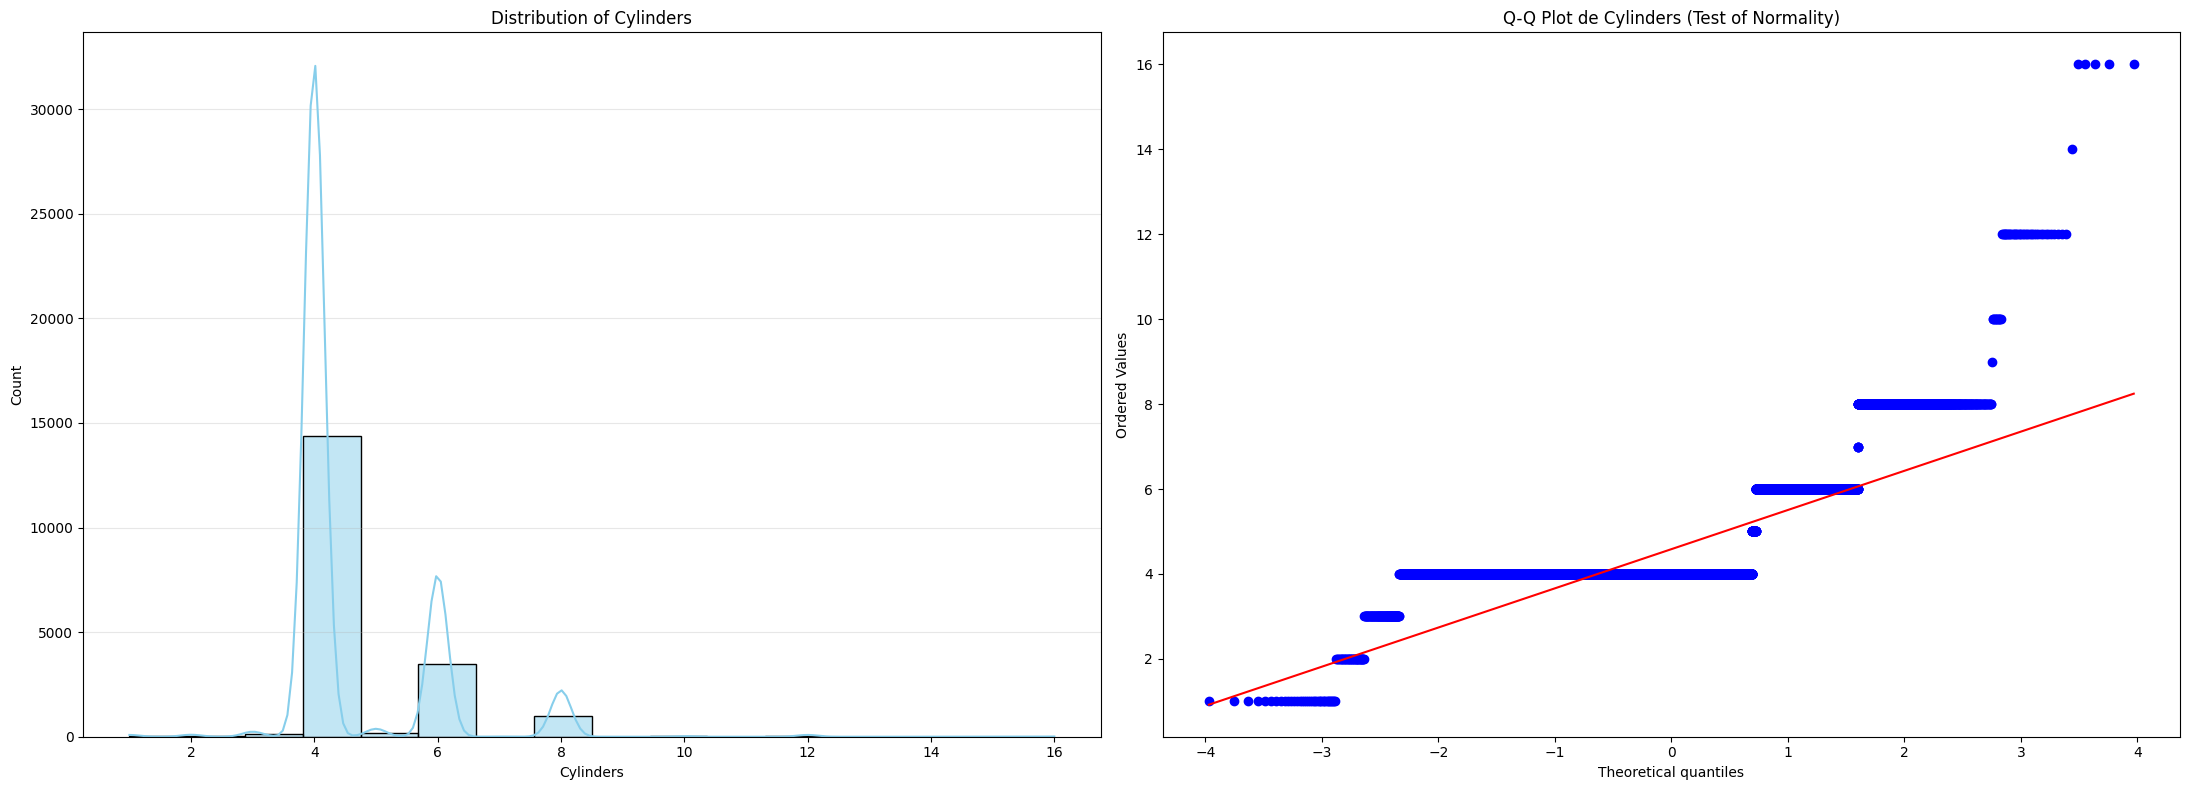

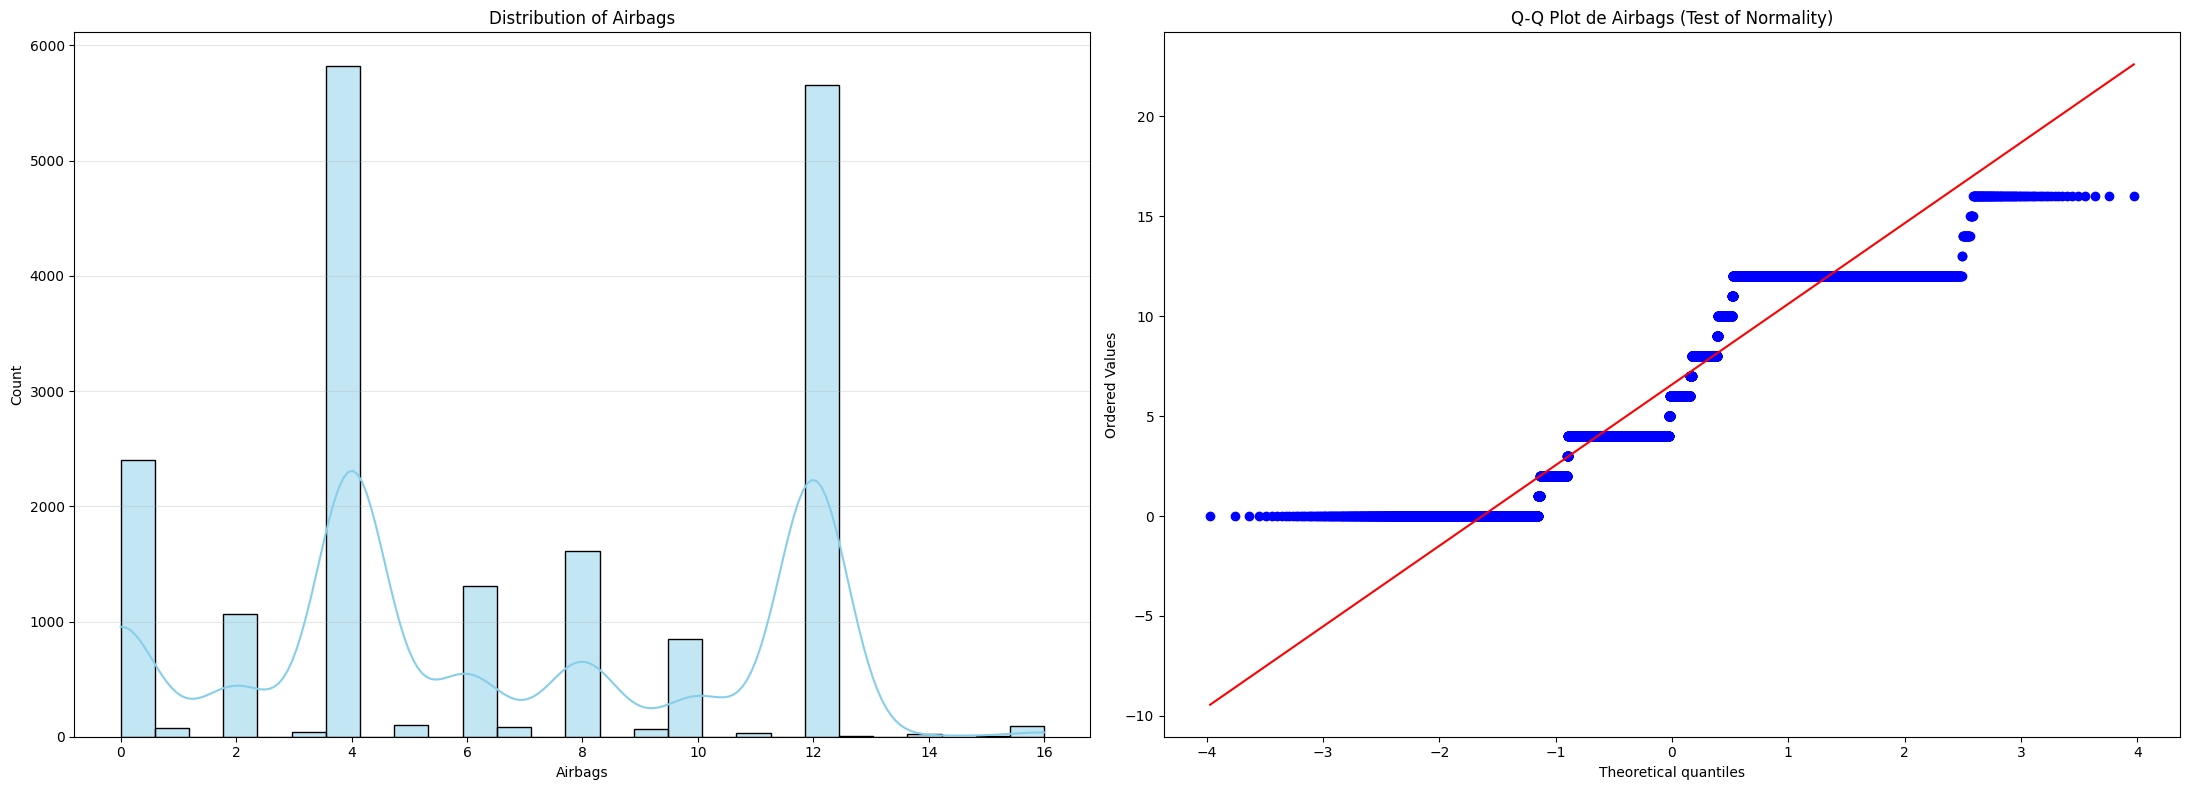

In [10]:
from scipy import stats  #  Q-Q Plot

for column in numbers_cols:
  
    if column == 'Price':
        continue
        
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))    
    
    # Histogramme (Courbe KDE)
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True, color='skyblue')
    plt.title(f'Distribution of {column}')
    plt.grid(axis='y', alpha=0.3)

    # Q-Q Plot (Droite de probabilité)

    plt.subplot(1, 2, 2)
    stats.probplot(df[column], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot de {column} (Test of Normality)')
    
    plt.tight_layout()
    plt.show()

## Correlation analysis

In [11]:
pd.set_option('display.max_columns', None)
df[numbers_cols].corr()


,Price,Prod. year,Cylinders,Airbags
Price,1.000000,0.012982,0.007518,-0.012824
Prod. year,0.012982,1.000000,-0.096797,0.236969
Cylinders,0.007518,-0.096797,1.000000,0.176868
Airbags,-0.012824,0.236969,0.176868,1.000000


<Axes: title={'center': 'Correlation with the target column'}>

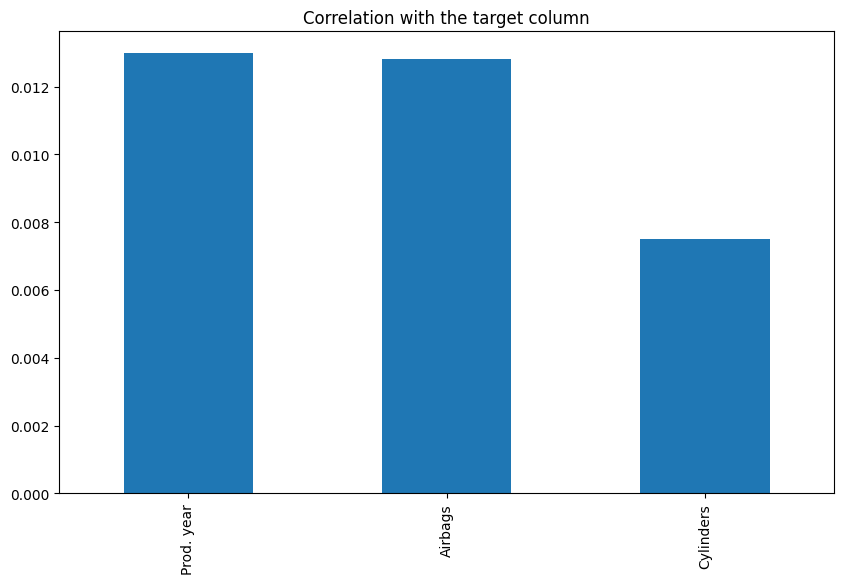

In [12]:
plt.figure(figsize=(10,6))
abs(df[numbers_cols].corr()['Price']).sort_values(ascending = False)[1:].plot(kind = 'bar', title = 'Correlation with the target column')

# Machine Learning 

## Training of models

In [13]:
mlss = []
X = df.drop(['Price'], axis=1)
y = df['Price']
numbers_cols, categorical_cols = get_cols(X)

for name_ml, ml in mls.items():
    for name_scaler_cat, scaler_cat in scalers_categorial.items():
        #  Encodage catégorical
        data_cat = encode_categorial(name_scaler_cat, scaler_cat, X, y)
        
        for name_scaler, scaler in scalers.items():
            #  Encodage numbers
            data_num = encode_number(name_scaler, scaler, X[numbers_cols])
            
            # Fusion 
            data_final = pd.concat([pd.DataFrame(data_cat, index=X.index), 
                                  pd.DataFrame(data_num, index=X.index)], axis=1)
            data_final.columns = categorical_cols + numbers_cols

            # Spliter 60% Train / 20% Val / 20% Test 
            X_train_full, X_test, y_train_full, y_test = train_test_split(
                data_final, y, test_size=0.20, random_state=42
            )
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_full, y_train_full, test_size=0.25, random_state=42
            )

            # 4. trainning
            model = ml.fit(X_train, y_train)
            
            score_val = round(model.score(X_val, y_val), 3)
            score_test = round(model.score(X_test, y_test), 3)
        
            mlss.append([name_ml, name_scaler_cat, name_scaler, score_val, score_test])

#  resultats
results_df = pd.DataFrame(mlss, columns=['Model', 'Cat_Scaler', 'Num_Scaler', 'Val_Score', 'Test_Score'])
print(results_df.sort_values(by='Val_Score', ascending=False))


                        Model     Cat_Scaler      Num_Scaler  Val_Score  \
67        ExtraTreesRegressor  TargetEncoder    RobustScaler      0.848   
66        ExtraTreesRegressor  TargetEncoder    MinMaxScaler      0.848   
65        ExtraTreesRegressor  TargetEncoder  StandardScaler      0.848   
69        ExtraTreesRegressor  TargetEncoder      Not scaled      0.848   
68        ExtraTreesRegressor  TargetEncoder      Normalizer      0.825   
..                        ...            ...             ...        ...   
3   GradientBoostingRegressor   LabelEncoder      Normalizer   -150.770   
4   GradientBoostingRegressor   LabelEncoder      Not scaled   -158.009   
2   GradientBoostingRegressor   LabelEncoder    RobustScaler   -158.009   
0   GradientBoostingRegressor   LabelEncoder  StandardScaler   -158.009   
1   GradientBoostingRegressor   LabelEncoder    MinMaxScaler   -158.009   

    Test_Score  
67       0.758  
66       0.758  
65       0.758  
69       0.758  
68       0.729

In [14]:
results_df

,Model,Cat_Scaler,Num_Scaler,Val_Score,Test_Score
0,GradientBoostingRegressor,LabelEncoder,StandardScaler,-158.009,-568.980
1,GradientBoostingRegressor,LabelEncoder,MinMaxScaler,-158.009,-568.980
2,GradientBoostingRegressor,LabelEncoder,RobustScaler,-158.009,-568.980
3,GradientBoostingRegressor,LabelEncoder,Normalizer,-150.770,-565.071
4,GradientBoostingRegressor,LabelEncoder,Not scaled,-158.009,-568.980
...,...,...,...,...,...
65,ExtraTreesRegressor,TargetEncoder,StandardScaler,0.848,0.758
66,ExtraTreesRegressor,TargetEncoder,MinMaxScaler,0.848,0.758
67,ExtraTreesRegressor,TargetEncoder,RobustScaler,0.848,0.758
68,ExtraTreesRegressor,TargetEncoder,Normalizer,0.825,0.729


## Identification of the best model

In [15]:
#  Identification of the best model (based on the Validation score)
best_run = results_df.sort_values(by='Val_Score', ascending=False).iloc[0]

print("--- MEILLEURE CONFIGURATION TROUVÉE ---")
print(f"Modèle      : {best_run['Model']}")
print(f"Scaler Cat  : {best_run['Cat_Scaler']}")
print(f"Scaler Num  : {best_run['Num_Scaler']}")
print(f"Score Val   : {best_run['Val_Score']}")
print(f"Score Test  : {best_run['Test_Score']}")

#   Top 5 
print("\n--- TOP 5  ---")
print(results_df.nlargest(5, 'Val_Score'))

--- MEILLEURE CONFIGURATION TROUVÉE ---
Modèle      : ExtraTreesRegressor
Scaler Cat  : TargetEncoder
Scaler Num  : RobustScaler
Score Val   : 0.848
Score Test  : 0.758

--- TOP 5  ---
                  Model     Cat_Scaler      Num_Scaler  Val_Score  Test_Score
65  ExtraTreesRegressor  TargetEncoder  StandardScaler      0.848       0.758
66  ExtraTreesRegressor  TargetEncoder    MinMaxScaler      0.848       0.758
67  ExtraTreesRegressor  TargetEncoder    RobustScaler      0.848       0.758
69  ExtraTreesRegressor  TargetEncoder      Not scaled      0.848       0.758
68  ExtraTreesRegressor  TargetEncoder      Normalizer      0.825       0.729


Why choose according to the Val_Score?

-Avoid over-learning: If you choose according to the Test_Score, you risk selecting a model who was "lucky" on the test.

-Generalization: The validation score is your compass during development. The test score is the final validation (the "real world").

-Consistency: If the difference between Val_Score and Test_Score is very large (>10%), your model is probably unstable.

## Complete pipeline backup

In [16]:
# Best configuration
best_row = results_df.sort_values(by='Val_Score', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_cat_scaler_name = best_row['Cat_Scaler']
best_num_scaler_name = best_row['Num_Scaler']

#  transformators
final_scaler_cat = scalers_categorial[best_cat_scaler_name]
final_scaler_num = scalers[best_num_scaler_name]
final_model = mls[best_model_name]

# Retraining on Train + Val (X_train_full) to maximize learning
# Processing of categories
X_cat_final = encode_categorial(best_cat_scaler_name, final_scaler_cat, X_train_full, y_train_full)
# Processing of numbers
X_num_final = encode_number(best_num_scaler_name, final_scaler_num, X_train_full[numbers_cols])

# Fusion 
X_final_train = np.hstack([X_cat_final, X_num_final])
final_model.fit(X_final_train, y_train_full)

# Group Backup (Model + Scalers + Columns)
pipeline_data = {
    'model': final_model,
    'scaler_cat': final_scaler_cat,
    'scaler_num': final_scaler_num,
    'features_num': numbers_cols,
    'features_cat': categorical_cols,
    'config': best_row.to_dict()
}

joblib.dump(pipeline_data, 'best_ml_pipeline_2025.pkl')

print(f"Success! Complete pipeline saved with {best_model_name}")
print(f"Final accuracy verified (Test Score): {best_row['Test_Score']}")

Success! Complete pipeline saved with ExtraTreesRegressor
Final accuracy verified (Test Score): 0.758


## Using the pipeline

In [17]:
# Loading the file
#pipeline = joblib.load('best_ml_pipeline_2025.pkl')

# Prediction on a new data 'new_data' (DataFrame) :
# Apply saved scalers (transform only, no fit)

# cat_encoded = pipeline['scaler_cat'].transform(new_data[pipeline['features_cat']])
# num_scaled = pipeline['scaler_num'].transform(new_data[pipeline['features_num']])

# Prediction
# prediction = pipeline['model'].predict(np.hstack([cat_encoded, num_scaled]))
